# Ridge Regression — A Complete Walkthrough on California Housing

**Goal:** predict the median house value of a California census block from neighborhood
features, using **ridge regression** (ordinary least squares with an L2 penalty).

> **Dataset:** 20,640 California census blocks, target = `median_house_value` (USD).

## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(suppress=True, precision=4)

In [2]:
# Load locally if present, otherwise fetch the public StatLib mirror so the
# notebook is self-contained and reproducible anywhere with internet access.
import os
URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv("housing.csv") if os.path.exists("housing.csv") else pd.read_csv(URL)
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 4. Exploratory analysis — motivating the penalty

Before modeling, two quick checks: what the target looks like, and how correlated the
predictors are. The second is the real motivation for ridge.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


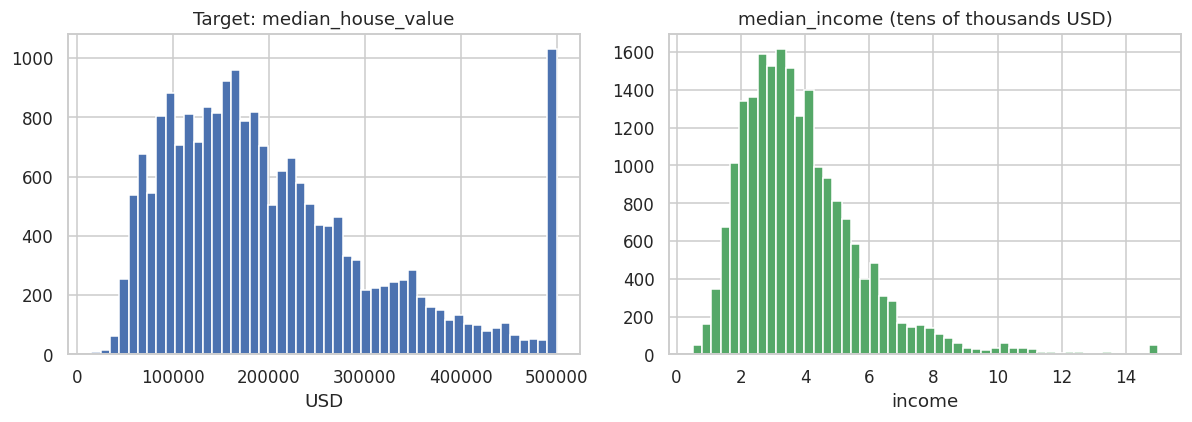

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["median_house_value"].hist(bins=50, ax=axes[0], color="#4c72b0")
axes[0].set_title("Target: median_house_value")
axes[0].set_xlabel("USD")
# Note the spike at the top: the target was capped at $500,001 in the original data.
df["median_income"].hist(bins=50, ax=axes[1], color="#55a868")
axes[1].set_title("median_income (tens of thousands USD)")
axes[1].set_xlabel("income")
plt.tight_layout()
plt.show()

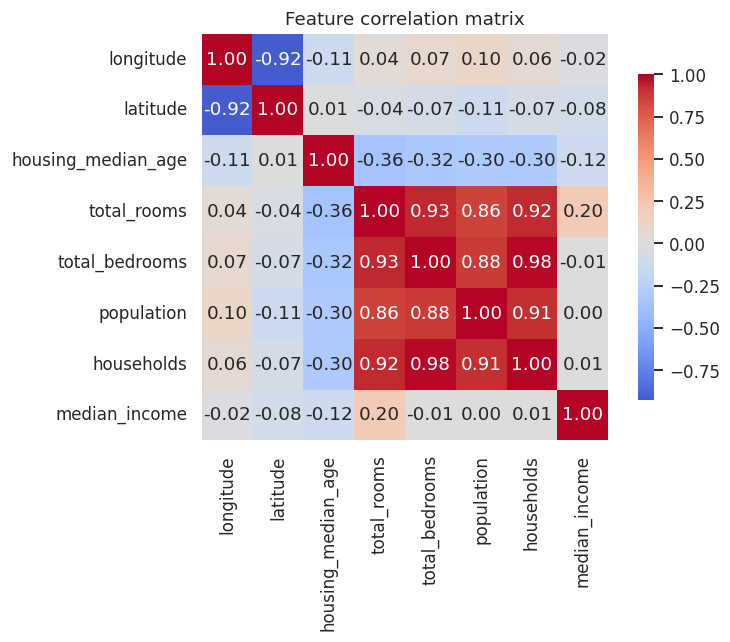

In [5]:
num_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
            "total_bedrooms", "population", "households", "median_income"]
corr = df[num_cols].corr()

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [6]:
X_num = df[num_cols].fillna(df[num_cols].median())
X_std = ((X_num - X_num.mean()) / X_num.std()).values
cond_XtX = np.linalg.cond(X_std.T @ X_std)
print(f"Condition number of X^T X (standardized features): {cond_XtX:,.0f}")
print("(Rule of thumb: a condition number above ~100 signals problematic multicollinearity.)")

Condition number of X^T X (standardized features): 198
(Rule of thumb: a condition number above ~100 signals problematic multicollinearity.)


## Train/test split

In [ ]:
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows")

Train: 16,512 rows   Test: 4,128 rows


## 6. Leakage-safe preprocessing pipeline

In [8]:
num_features = num_cols
cat_features = ["ocean_proximity"]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 7. Baseline OLS

We score with **root mean squared error (RMSE)**, in dollars. `cross_val_score` returns the
*negative* MSE (scikit-learn convention: higher is better), so we negate and take the square
root. 5-fold CV on the training set gives an honest estimate without touching the test set.

In [9]:
def cv_rmse(model, X, y, cv=5):
    neg_mse = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv)
    return np.sqrt(-neg_mse)

ols = Pipeline([("prep", preprocess), ("model", LinearRegression())])
ols_rmse = cv_rmse(ols, X_train, y_train)
print(f"OLS  5-fold CV RMSE: {ols_rmse.mean():,.0f}  (+/- {ols_rmse.std():,.0f})")

OLS  5-fold CV RMSE: 68,623  (+/- 1,439)


## 8. Tuning ridge's $\alpha$ with cross-validation

$\alpha$ is the one hyperparameter that matters. Too small and ridge behaves like OLS; too
large and it underfits. We grid-search over a log-spaced range and pick the value with the
best CV RMSE.

In [10]:
alphas = np.logspace(-2, 5, 40)

ridge_pipe = Pipeline([("prep", preprocess), ("model", Ridge())])
grid = GridSearchCV(
    ridge_pipe,
    param_grid={"model__alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5,
)
grid.fit(X_train, y_train)

best_alpha = grid.best_params_["model__alpha"]
best_rmse = np.sqrt(-grid.best_score_)
print(f"Best alpha: {best_alpha:.3f}")
print(f"Ridge 5-fold CV RMSE: {best_rmse:,.0f}")
print(f"OLS   5-fold CV RMSE: {ols_rmse.mean():,.0f}")

Best alpha: 0.624
Ridge 5-fold CV RMSE: 68,637
OLS   5-fold CV RMSE: 68,623


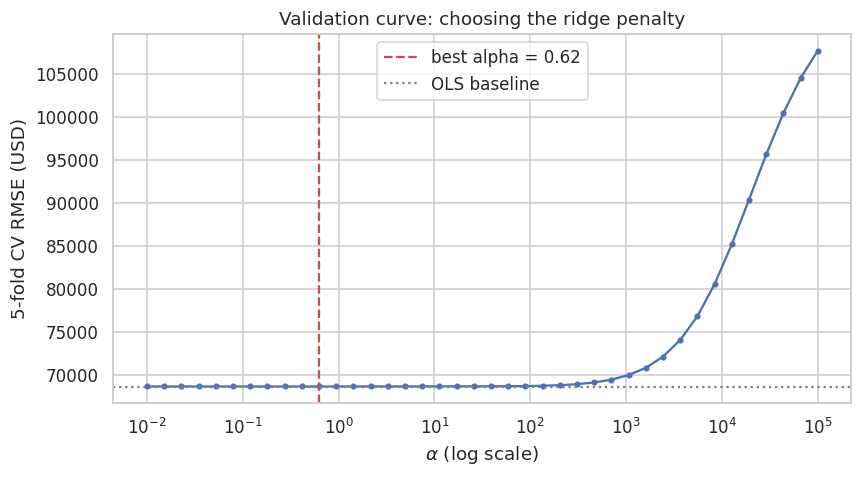

In [11]:
# Validation curve: CV RMSE as a function of alpha
cv_rmse_path = np.sqrt(-grid.cv_results_["mean_test_score"])

plt.figure(figsize=(8, 4.5))
plt.semilogx(alphas, cv_rmse_path, marker="o", ms=3, color="#4c72b0")
plt.axvline(best_alpha, color="#c44e52", ls="--",
            label=f"best alpha = {best_alpha:.2f}")
plt.axhline(ols_rmse.mean(), color="grey", ls=":", label="OLS baseline")
plt.xlabel(r"$\alpha$ (log scale)")
plt.ylabel("5-fold CV RMSE (USD)")
plt.title("Validation curve: choosing the ridge penalty")
plt.legend()
plt.tight_layout()
plt.show()

## 9. The regularization path

The iconic ridge picture: every coefficient as a function of $\alpha$. As the penalty grows,
coefficients shrink smoothly toward (but never reach) zero. To make this readable we fit on the
preprocessed **numeric** features only, so each line is a named feature.

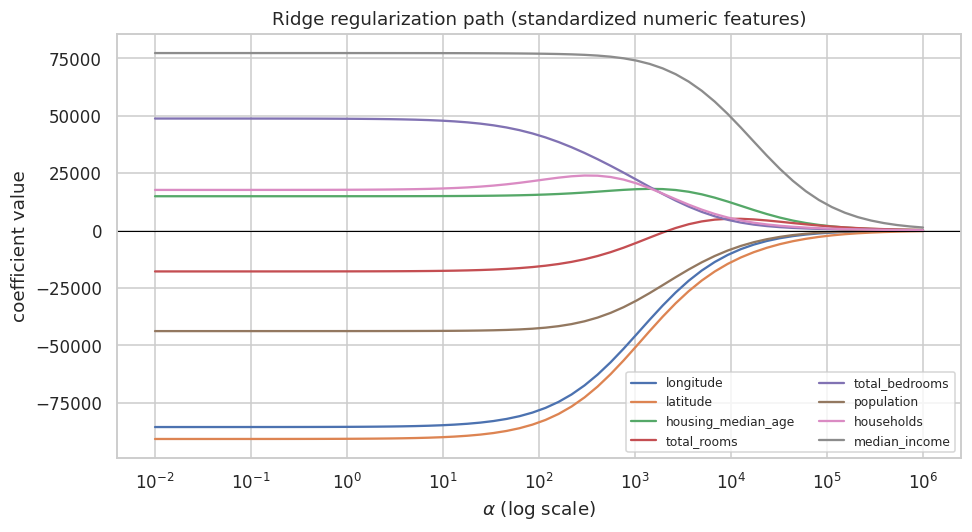

In [ ]:
# Preprocess once (fit on training data) to get a clean numeric design matrix.
num_only = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
Z_train = num_only.fit_transform(X_train[num_features])

path_alphas = np.logspace(-2, 6, 60)
coefs = []
for a in path_alphas:
    r = Ridge(alpha=a).fit(Z_train, y_train)
    coefs.append(r.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(9, 5))
for j, name in enumerate(num_features):
    plt.plot(path_alphas, coefs[:, j], label=name)
plt.xscale("log")
plt.xlabel(r"$\alpha$ (log scale)")
plt.ylabel("coefficient value")
plt.title("Ridge regularization path (standardized numeric features)")
plt.axhline(0, color="black", lw=0.7)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

`median_income` (the strongest, most independent predictor) holds its weight the longest,
while the mutually-redundant count features — which OLS gives large, opposing coefficients to
in order to cancel each other out — are pulled toward zero quickly. That cancellation is
exactly the instability ridge is taming.

## 10. OLS vs ridge coefficients side by side

At this dataset's CV-optimal $\alpha \approx 0.62$, ridge and OLS coefficients are **nearly
identical** — with 16k rows there is enough data that little shrinkage is warranted, the honest
result we saw above. To actually *see* the shrinkage mechanism, we add a third bar at a
deliberately larger $\alpha = 10^4$. Watch the redundant count features collapse toward zero
while `median_income` — the strong, independent signal — holds on.

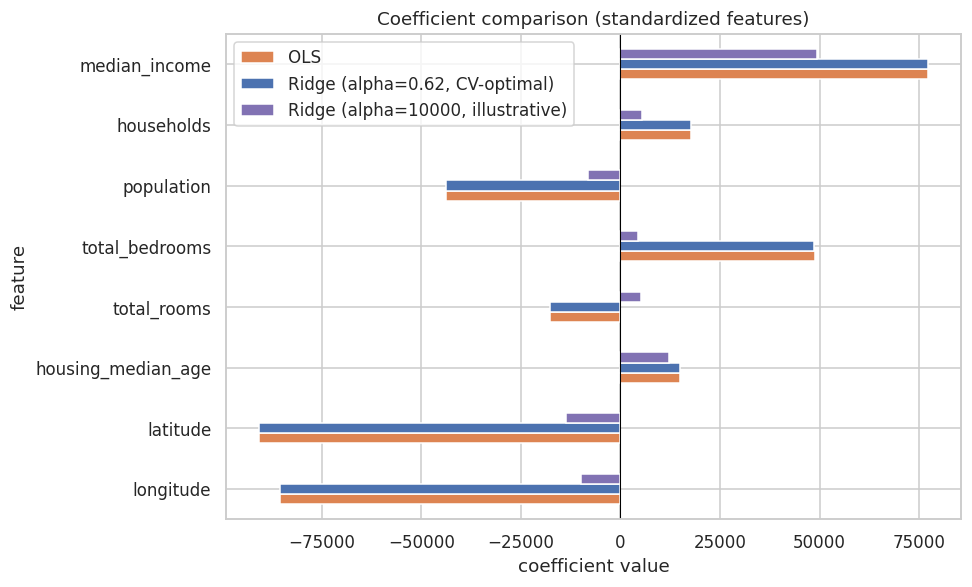

,OLS,"Ridge (alpha=0.62, CV-optimal)","Ridge (alpha=10000, illustrative)"
feature,,,
longitude,-85503.0,-85453.0,-9950.0
latitude,-90699.0,-90649.0,-13772.0
housing_median_age,14906.0,14910.0,12138.0
total_rooms,-17805.0,-17789.0,5115.0
total_bedrooms,48712.0,48651.0,4312.0
population,-43766.0,-43761.0,-8173.0
households,17655.0,17696.0,5295.0
median_income,77195.0,77193.0,49262.0


In [13]:
ALPHA_ILLUS = 1e4   # larger than CV-optimal, purely to make the shrinkage visible
ols_num = LinearRegression().fit(Z_train, y_train)
ridge_num = Ridge(alpha=best_alpha).fit(Z_train, y_train)
ridge_big = Ridge(alpha=ALPHA_ILLUS).fit(Z_train, y_train)

comp = pd.DataFrame({
    "feature": num_features,
    "OLS": ols_num.coef_,
    f"Ridge (alpha={best_alpha:.2f}, CV-optimal)": ridge_num.coef_,
    f"Ridge (alpha={ALPHA_ILLUS:.0f}, illustrative)": ridge_big.coef_,
}).set_index("feature")

ax = comp.plot(kind="barh", figsize=(9, 5.5), color=["#dd8452", "#4c72b0", "#8172b3"])
ax.axvline(0, color="black", lw=0.7)
ax.set_title("Coefficient comparison (standardized features)")
ax.set_xlabel("coefficient value")
plt.tight_layout()
plt.show()
comp.round(0)

## Ridge from scratch 

To confirm the math from Section 2, we implement
$\hat\beta = (X^\top X + \alpha I)^{-1} X^\top y$ by hand. To match scikit-learn (which does
**not** penalize the intercept), we center $X$ and $y$, solve for the slopes on the centered
data, then recover the intercept as $\bar y - \bar X \hat\beta$.

In [14]:
def ridge_closed_form(X, y, alpha):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - X_mean, y - y_mean
    n_features = Xc.shape[1]
    A = Xc.T @ Xc + alpha * np.eye(n_features)
    beta = np.linalg.solve(A, Xc.T @ yc)      # slopes (intercept unpenalized)
    intercept = y_mean - X_mean @ beta
    return beta, intercept

beta_scratch, b0_scratch = ridge_closed_form(Z_train, y_train.values, best_alpha)

print("Max |coef difference| vs sklearn:",
      np.max(np.abs(beta_scratch - ridge_num.coef_)))
print("Intercept difference vs sklearn:",
      abs(b0_scratch - ridge_num.intercept_))
print("\nMatches scikit-learn to numerical precision:",
      np.allclose(beta_scratch, ridge_num.coef_) and
      np.isclose(b0_scratch, ridge_num.intercept_))

Max |coef difference| vs sklearn: 1.1641532182693481e-10
Intercept difference vs sklearn: 0.0

Matches scikit-learn to numerical precision: True


## 12. Ridge vs Lasso

In [15]:
ALPHA_DEMO = 5000   # large enough that the L1 sparsity effect is visible
ridge_demo = Ridge(alpha=ALPHA_DEMO).fit(Z_train, y_train)
lasso_demo = Lasso(alpha=ALPHA_DEMO, max_iter=20000).fit(Z_train, y_train)

sparsity = pd.DataFrame({
    "feature": num_features,
    "Ridge": ridge_demo.coef_,
    "Lasso": lasso_demo.coef_,
}).set_index("feature").round(0)

n_zero = int(np.sum(np.isclose(lasso_demo.coef_, 0)))
print(f"At alpha={ALPHA_DEMO}: lasso sets {n_zero} of {len(num_features)} "
      f"coefficients to exactly zero; ridge keeps all of them (just smaller).")
sparsity

At alpha=5000: lasso sets 3 of 8 coefficients to exactly zero; ridge keeps all of them (just smaller).


,Ridge,Lasso
feature,,
longitude,-17309.0,-20209.0
latitude,-21649.0,-24208.0
housing_median_age,15697.0,16147.0
total_rooms,3981.0,0.0
total_bedrooms,8041.0,6229.0
population,-13761.0,-0.0
households,9020.0,0.0
median_income,60665.0,74676.0


## 13. Final evaluation on the held-out test set

Everything above used only the training set (via cross-validation) for model selection. We now
refit the best ridge pipeline on the **full training set** and evaluate **once** on the test
set we set aside in Section 5. This is the only number that estimates real-world performance.

In [16]:
best_model = grid.best_estimator_          # already refit on all of X_train by GridSearchCV
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Held-out test performance (ridge, alpha={best_alpha:.2f}):")
print(f"  RMSE : ${rmse:,.0f}")
print(f"  MAE  : ${mae:,.0f}")
print(f"  R^2  : {r2:.3f}")

Held-out test performance (ridge, alpha=0.62):
  RMSE : $70,064
  MAE  : $50,675
  R^2  : 0.625


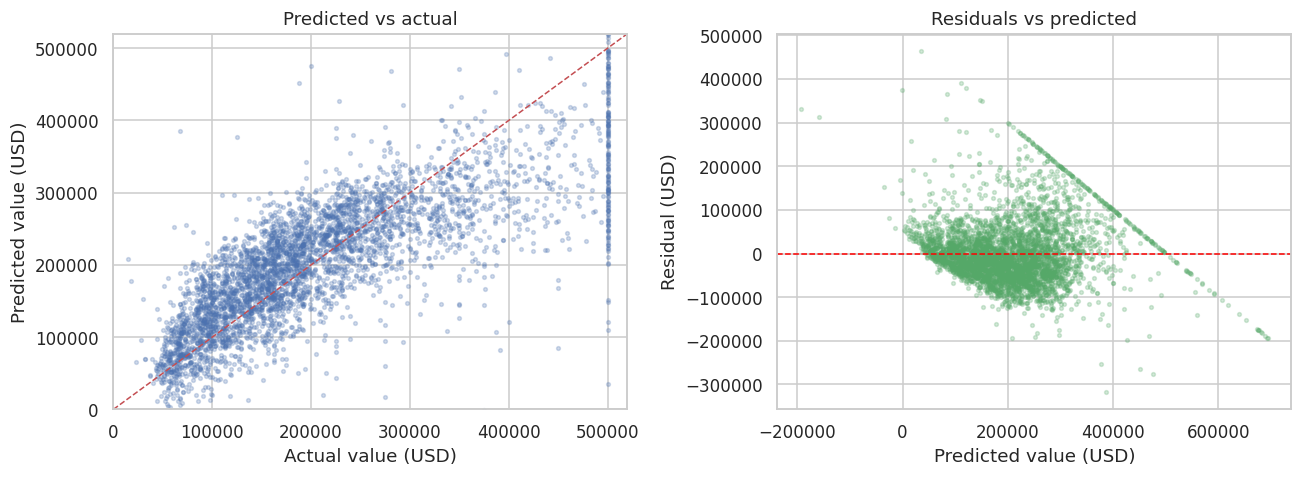

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, s=6, alpha=0.25, color="#4c72b0")
lims = [0, 520000]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual value (USD)")
axes[0].set_ylabel("Predicted value (USD)")
axes[0].set_title("Predicted vs actual")

# Residuals
resid = y_test - y_pred
axes[1].scatter(y_pred, resid, s=6, alpha=0.25, color="#55a868")
axes[1].axhline(0, color="red", ls="--", lw=1)
axes[1].set_xlabel("Predicted value (USD)")
axes[1].set_ylabel("Residual (USD)")
axes[1].set_title("Residuals vs predicted")

plt.tight_layout()
plt.show()

## 14. Takeaways

- **Ridge = OLS + L2 penalty.** It trades a little bias for much lower variance and a stable,
  always-invertible solution — valuable whenever predictors are collinear or features are
  numerous relative to samples.
- **Always standardize** before ridge; the penalty is scale-sensitive.
- **Tune $\alpha$ by cross-validation**, and do *all* preprocessing inside a pipeline so no
  test information leaks into training.
- On this dataset ridge mainly bought **stability** rather than a large accuracy gain, because
  the data is plentiful relative to the feature count.
- The closed form $(X^\top X + \alpha I)^{-1}X^\top y$ reproduces scikit-learn exactly.